<a href="https://colab.research.google.com/github/bushra-safa-23/Diabetes-prediction-project/blob/main/diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title: Diabetes Prediction**





Objective: Using machine learning techniques to predict if a patient has diabetes or no diabetes.Since the target variable has two categories( Diabetes: 1, No Diabetes: 0), it is a classification problem.

Source: Kaggle

Dataset:`uciml/pima-indians-diabetes-database`  

File: `diabetes.csv`



**1)** **Installing Kaggle**


In [ ]:
!pip install kaggle

**2)** **Loading Kaggle Token**

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

**3)** **Testing Kaggle connection**

In [ ]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

**4)** **Downloading data set from Kaggle**

In [ ]:
!kaggle datasets download -d uciml/pima-indians-diabetes-database

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 19.6MB/s]



In [ ]:
!ls

pima-indians-diabetes-database.zip  sample_data


In [ ]:
!unzip pima-indians-diabetes-database.zip

Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            


In [ ]:
!ls

diabetes.csv  pima-indians-diabetes-database.zip  sample_data


**5)** **Reading csv file using pandas**

In [ ]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Initially checking data after downloading data set**
**6)Checking rows and columns**

In [ ]:
df.shape

(768, 9)

**7) column names**

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

**8) Checking data summary**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**9) Import required libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

**10) Again checking data**

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**11) Checking missing values and duplicates**

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

**12) Removing duplicates**

In [ ]:

df = df.drop_duplicates()


df.duplicated().sum()

np.int64(0)

**13) Invalid zero values as missing**

In [ ]:
zero_not_allowed = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_not_allowed:
    print(col, "zero values:", (df[col] == 0).sum())

Glucose zero values: 5
BloodPressure zero values: 35
SkinThickness zero values: 227
Insulin zero values: 374
BMI zero values: 11


In [ ]:
df[zero_not_allowed] = df[zero_not_allowed].replace(0, np.nan)
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**14) Fill missing values with median**

In [ ]:
for col in zero_not_allowed:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**EDA**

**15) Target variable distribution**

In [ ]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


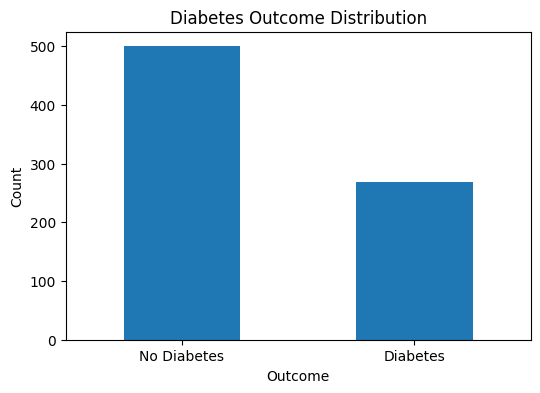

In [ ]:
plt.figure(figsize=(6,4))
df["Outcome"].value_counts().plot(kind="bar")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)
plt.show()

**The target variable shows the patients with diabetes and no diabetes. This helps us to understand whether the dataset is balanced or imbalanced.**

**16) Histograms for features**

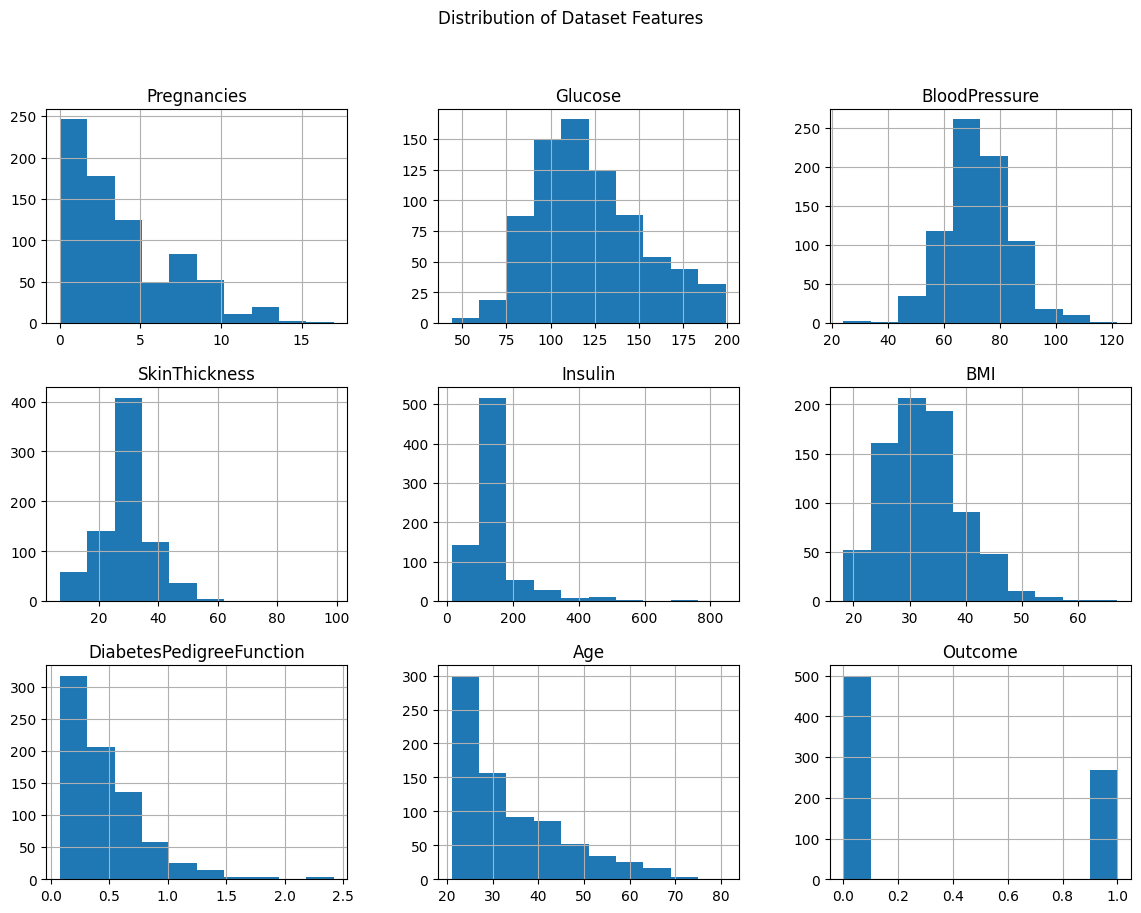

In [ ]:
df.hist(figsize=(14,10))
plt.suptitle("Distribution of Dataset Features")
plt.show()

**The histograms show the distribution of each variable to check skewness, unusual values, and general patterns in the dataset.**

**17) Boxplot for outliars**

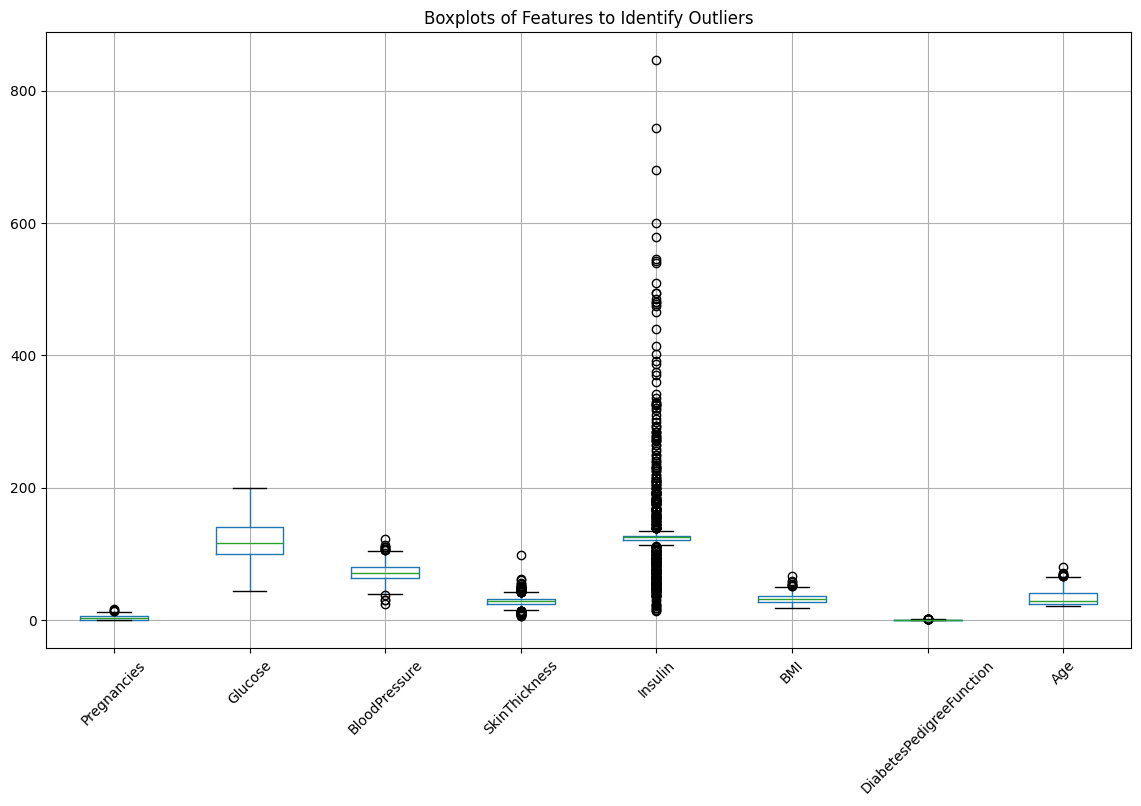

In [ ]:
features = df.drop("Outcome", axis=1).columns

plt.figure(figsize=(14,8))
df[features].boxplot()
plt.title("Boxplots of Features to Identify Outliers")
plt.xticks(rotation=45)
plt.show()

**Outliers are different from usual data. The boxplot identify the outliers in dataset.**

**18) Correlation matrix**

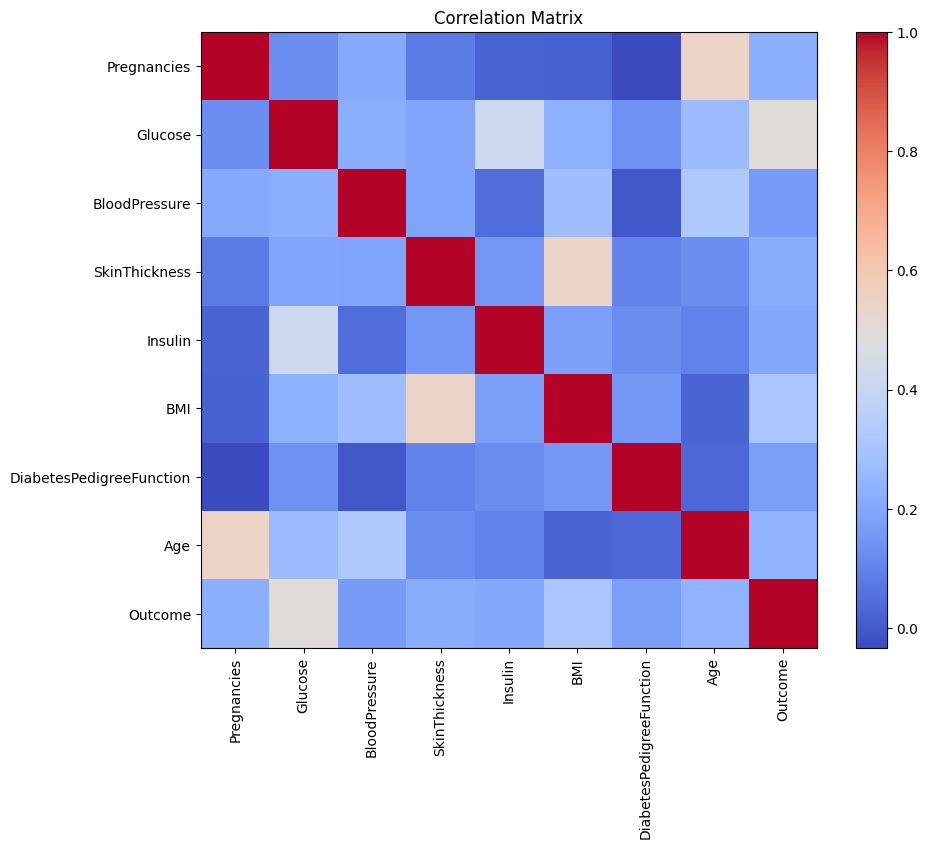

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.corr()["Outcome"].sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.492782
BMI,0.312038
Age,0.238356
Pregnancies,0.221898
SkinThickness,0.214873
Insulin,0.203790
DiabetesPedigreeFunction,0.173844
BloodPressure,0.165723


**Correlation shows relationship between variables and outcomes.**

**19) Handle outliers using IQR**

In [ ]:

df_clean = df.copy()


def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])
    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column])

    return data

for col in features:
    df_clean = cap_outliers_iqr(df_clean, col)

df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.656250,72.358073,28.866536,124.691081,32.393359,0.458914,33.199870,0.348958
std,3.344157,30.438286,11.697097,7.442353,7.913595,6.667471,0.285596,11.628404,0.476951
min,0.000000,44.000000,40.000000,14.500000,112.875000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,104.000000,42.500000,135.875000,50.250000,1.200000,66.500000,1.000000


**Outliers were handled using the IQR method. Instead of removing rows, extreme values were capped at acceptable lower and upper limits. This helps reduce the effect of extreme values while keeping the dataset size unchanged.**

**20) Features X and target y**

In [ ]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

In [ ]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,125.000,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,125.000,26.6,0.351,31.0
2,8.0,183.0,64.0,29.0,125.000,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,112.875,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,135.875,43.1,1.200,33.0


In [ ]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


**The feature matrix X= Independent variables.**
 **The target vector y= The diabetes outcome.**

**21) Feature scaling**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.647150,0.866045,-0.030632,0.824667,0.039062,0.181092,0.588927,1.445691
1,-0.848970,-1.205066,-0.543914,0.017945,0.039062,-0.869465,-0.378101,-0.189304
2,1.245598,2.016662,-0.715008,0.017945,0.039062,-1.364728,0.746595,-0.103252
3,-0.848970,-1.073567,-0.543914,-0.788777,-1.494110,-0.644346,-1.022787,-1.049828
4,-1.148194,0.504422,-2.768136,0.824667,1.414175,1.606849,2.596563,-0.017199


**StandardScaler transforms the features so they have a mean of 0 and standard deviation of 1. **

**22) Feature selection**

**Will use SelectKBest**

In [ ]:
selector = SelectKBest(score_func=mutual_info_classif, k="all")
selector.fit(X_scaled, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(by="Score", ascending=False)
feature_scores

,Feature,Score
1,Glucose,0.128110
5,BMI,0.088035
7,Age,0.054755
4,Insulin,0.028113
0,Pregnancies,0.026236
6,DiabetesPedigreeFunction,0.008153
3,SkinThickness,0.000000
2,BloodPressure,0.000000


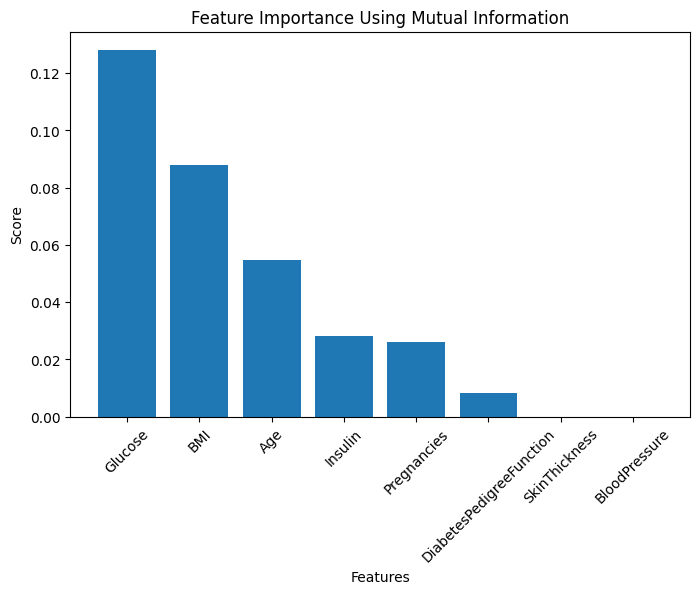

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(feature_scores["Feature"], feature_scores["Score"])
plt.title("Feature Importance Using Mutual Information")
plt.xlabel("Features")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

**23) Top features**

**Top 6 features**

In [ ]:
top_features = feature_scores["Feature"].head(6).tolist()
top_features

['Glucose', 'BMI', 'Age', 'Insulin', 'Pregnancies', 'DiabetesPedigreeFunction']

In [ ]:
X_selected = X_scaled[top_features]
X_selected.head()

,Glucose,BMI,Age,Insulin,Pregnancies,DiabetesPedigreeFunction
0,0.866045,0.181092,1.445691,0.039062,0.647150,0.588927
1,-1.205066,-0.869465,-0.189304,0.039062,-0.848970,-0.378101
2,2.016662,-1.364728,-0.103252,0.039062,1.245598,0.746595
3,-1.073567,-0.644346,-1.049828,-1.494110,-0.848970,-1.022787
4,0.504422,1.606849,-0.017199,1.414175,-1.148194,2.596563


**24) Train-Test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 6)
X_test shape: (154, 6)
y_train shape: (614,)
y_test shape: (154,)


**The dataset was split into 80% training data and 20% testing data. **

**25) Classification models(multiples)**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

In [ ]:
results = []

for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict class
    y_pred = model.predict(X_test)

    # Predict probability for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.720779,0.617021,0.537037,0.574257,0.807778
1,Decision Tree,0.714286,0.608696,0.518519,0.560000,0.669259
2,Random Forest,0.766234,0.695652,0.592593,0.640000,0.826944
3,KNN,0.733766,0.638298,0.555556,0.594059,0.798241


**26) Comparison between model performance**

In [ ]:
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.766234,0.695652,0.592593,0.640000,0.826944
3,KNN,0.733766,0.638298,0.555556,0.594059,0.798241
0,Logistic Regression,0.720779,0.617021,0.537037,0.574257,0.807778
1,Decision Tree,0.714286,0.608696,0.518519,0.560000,0.669259


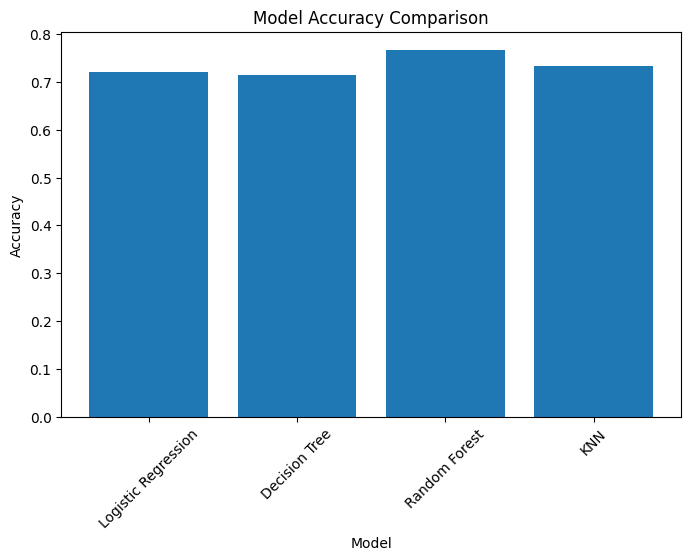

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

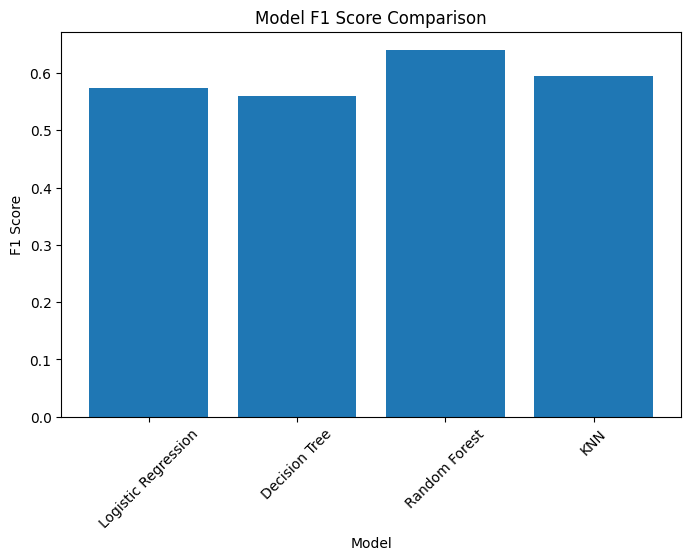

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

**Multiple classification models were trained and compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Among tem  recall and F1-score are especially important since missing a diabetes case may have serious consequences.**

**27) Selecting best model**

In [ ]:
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]
best_model_name

'Random Forest'

In [ ]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_prob_best = best_model.predict_proba(X_test)[:, 1]
else:
    y_prob_best = y_pred_best

**28) confusion matrix for best model**

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
cm

array([[86, 14],
       [22, 32]])

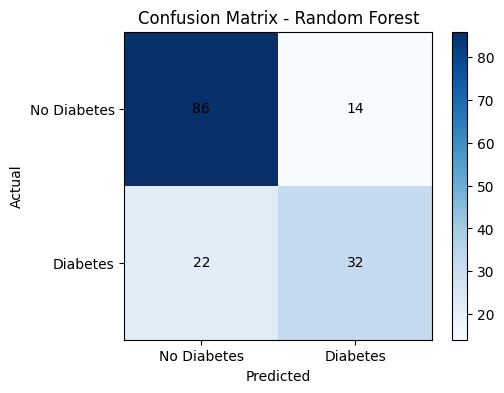

In [ ]:
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks([0,1], ["No Diabetes", "Diabetes"])
plt.yticks([0,1], ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



**The confusion matrix shows true positives are diabetes patients correctly predicted as diabetic, and true negatives are non-diabetes patients correctly predicted as non-diabetic.**

**29) ROC Curve**

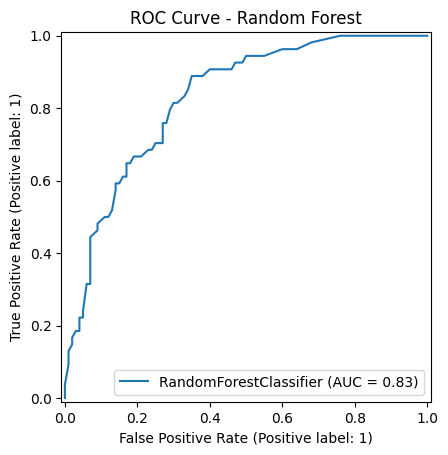

In [ ]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()

In [ ]:
roc_auc_score(y_test, y_prob_best)

np.float64(0.8269444444444445)

**30) Model optimization**

**Here will optimize a random forest model using gridsearch**

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [ ]:
grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
# Best optimized model
optimized_model = grid_search.best_estimator_

# Prediction using optimized model
y_pred_optimized = optimized_model.predict(X_test)
y_prob_optimized = optimized_model.predict_proba(X_test)[:, 1]

**31) Evaluate optimized model**

In [ ]:
optimized_results = {
    "Model": "Optimized Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_optimized),
    "Precision": precision_score(y_test, y_pred_optimized),
    "Recall": recall_score(y_test, y_pred_optimized),
    "F1 Score": f1_score(y_test, y_pred_optimized),
    "ROC-AUC": roc_auc_score(y_test, y_prob_optimized)
}

optimized_results

{'Model': 'Optimized Random Forest',
 'Accuracy': 0.7532467532467533,
 'Precision': 0.6666666666666666,
 'Recall': 0.5925925925925926,
 'F1 Score': 0.6274509803921569,
 'ROC-AUC': np.float64(0.8206481481481481)}

In [ ]:

final_results_df = pd.concat(
    [results_df, pd.DataFrame([optimized_results])],
    ignore_index=True
)

final_results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.766234,0.695652,0.592593,0.640000,0.826944
4,Optimized Random Forest,0.753247,0.666667,0.592593,0.627451,0.820648
3,KNN,0.733766,0.638298,0.555556,0.594059,0.798241
0,Logistic Regression,0.720779,0.617021,0.537037,0.574257,0.807778
1,Decision Tree,0.714286,0.608696,0.518519,0.560000,0.669259


In [ ]:
print(classification_report(y_test, y_pred_optimized))

              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



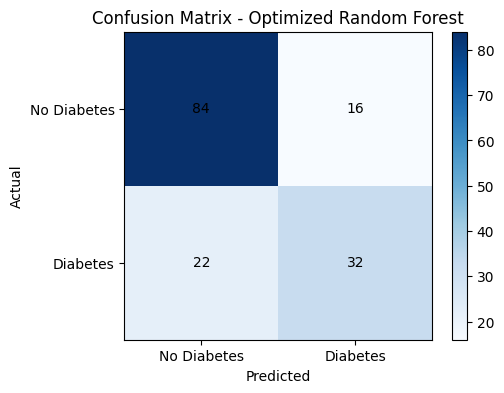

In [ ]:
cm_opt = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(5,4))
plt.imshow(cm_opt, cmap="Blues")
plt.title("Confusion Matrix - Optimized Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks([0,1], ["No Diabetes", "Diabetes"])
plt.yticks([0,1], ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_opt[i, j], ha="center", va="center")

plt.show()

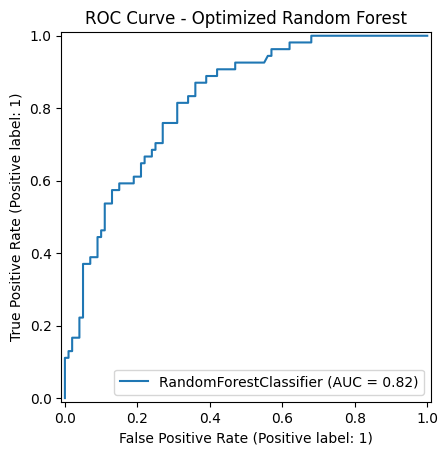

In [ ]:
RocCurveDisplay.from_estimator(optimized_model, X_test, y_test)
plt.title("ROC Curve - Optimized Random Forest")
plt.show()

**The Random Forest model was optimized using GridSearchCV. GridSearchCV tests different combinations of hyperparameters and selects the best combination based on F1-score. **





**32) Feature importance from optimized Random Forest**

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X_selected.columns,
    "Importance": optimized_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df

,Feature,Importance
0,Glucose,0.344950
1,BMI,0.199282
2,Age,0.152677
5,DiabetesPedigreeFunction,0.146245
4,Pregnancies,0.095003
3,Insulin,0.061843


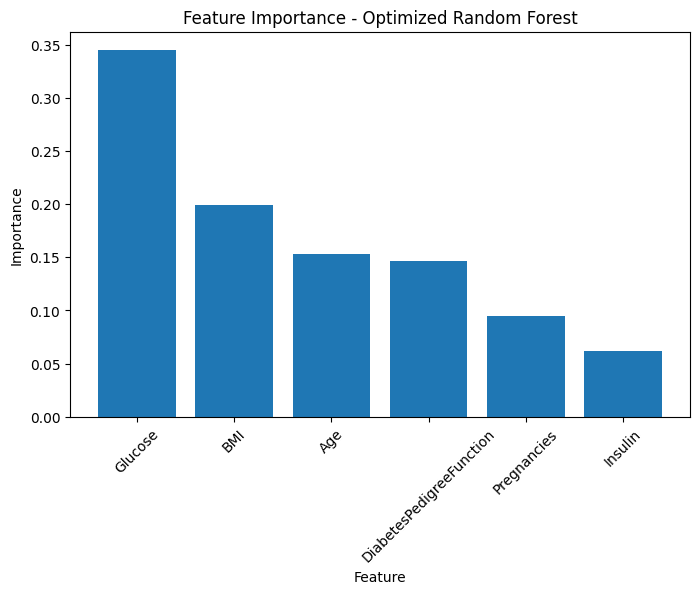

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance - Optimized Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

**Feature importance indicates which variables contributed most to the prediction.**

**33) Final evaluation**

In [ ]:
final_results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.766234,0.695652,0.592593,0.640000,0.826944
4,Optimized Random Forest,0.753247,0.666667,0.592593,0.627451,0.820648
3,KNN,0.733766,0.638298,0.555556,0.594059,0.798241
0,Logistic Regression,0.720779,0.617021,0.537037,0.574257,0.807778
1,Decision Tree,0.714286,0.608696,0.518519,0.560000,0.669259


**Model Evaluation:**

I used Accuracy, Precision, Recall, F1-score, and ROC-AUC for model evaluation.

For diabetes classification problem, recall is especially important because a false negative means a patient who has diabetes may be predicted as not having diabetes. This could create problem like delaying diagnosis and treatment.

To balance between precision and recall used F1-score.

The optimized model was selected as the final model as it provides the best balance between correct classification and identifying diabetes cases.

**Business Insights:**

 This model can help both patients and healthcare providers to identify the patterns of diabetes and can check wheather they have diabetes or not based on measurements. For example, people with higher glucose level,higher BMI, or aged person may have a higher likelihood of diabetes. This model can help identify those by measuring glucose level, BMI , blood pressure level,insulin and age.
 Hospitals, healthcare organizations and cliniques can use this model to identify diabetes patients and can categorize them in which patient needs what type of medical attention. This model also help in early screeing of diabetes.

**Recommendations:**

- Collection of more data to improve model performance.
- Train the model with collected new dataset.
- Use in early screeing.
- Help doctors and medical professionals to categorize patients risk   level and act according to that.
- Combined work of medical professionals and model accuracy to serve patients.

**Limitations:**

- Dataset is relatively small.
- Less variables.
- The model predicts risk but does not give final diagnosis.
- Some missing values were replaced using median values. But this makes it a safer choice when the dataset has outliers.

**Future Improvements:**

- Larger dataset.
- Diverse dataset
- Improving feature engineering.
- Using more advanced ML models.

**AI Usage:**

- Dataset recommendation.
- How to load dataset in colab.
- Used to understand the whole concept.
- Colab Gemini recommendation for step by step codes.
- Code organization and debugging.
- Review of full project to check if there is any error.